In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [3]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/palpablepalm_dataset.zip"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/palpablepalm_dataset.zip
  inflating: Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar  


In [4]:
!unrar x "/content/Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar

Creating    Palm                                                      OK
Extracting  Palm/Anemic-260 (10).png                                       0%  OK 
Extracting  Palm/Anemic-260 (11).png                                       0%  OK 
Extracting  Palm/Anemic-260 (12).png                                       0%  OK 
Extracting  Palm/Anemic-260 (2).png                                        0%  OK 
Extracting  Palm/Anemic-260 (3).png                                        0%  OK 
Extracting  Palm/Anemic-260 (4).png                                        0%  OK 
Extracting  Palm/Anemic-260 (5).png                                        0%  OK 
Extracting  Palm/Anemic-260 (6).png                                        0%  OK 
Extracting  Palm/

In [5]:
import os

os.listdir('/content')
dataset_path = "/content/Palm"
from glob import glob

images = glob(dataset_path + "/*.png")

print("Toplam görüntü:", len(images))
print(images[:5])

Toplam görüntü: 4260
['/content/Palm/AnemicP-079.png', '/content/Palm/AnemicP-101 (10).png', '/content/Palm/AnemicP-032 (4).png', '/content/Palm/AnemicP-100 (11).png', '/content/Palm/AnemicP-046 (3).png']


In [6]:
import os
from glob import glob

images = glob(dataset_path + "/*")

print("Toplam bulunan dosya:", len(images))
for x in images[:10]:
    print(repr(os.path.basename(x)))

Toplam bulunan dosya: 4260
'AnemicP-079.png'
'AnemicP-101 (10).png'
'AnemicP-032 (4).png'
'AnemicP-100 (11).png'
'AnemicP-046 (3).png'
'Non-AnemicP-057 (3).png'
'Non-AnemicP-021.png'
'AnemicP-113 (4).png'
'Non-AnemicP-055 (6).png'
'Non-AnemicP-001 (4).png'


In [7]:
import os
import re
import pandas as pd
from glob import glob

files = glob(os.path.join(dataset_path, "*.png"))

def parse_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    # augmentation numarası
    aug_match = re.search(r"\((\d+)\)$", stem)
    if aug_match:
        aug_no = int(aug_match.group(1))
        stem_core = re.sub(r"\s*\(\d+\)$", "", stem)
    else:
        aug_no = 1
        stem_core = stem

    lower = stem_core.lower()

    # sınıf
    if lower.startswith("non-anemic"):
        cls = "Non-Anemic"
        rest = stem_core[len("Non-Anemic-"):] if stem_core.startswith("Non-Anemic-") else stem_core[len("Non-anemic-"):]
    elif lower.startswith("anemic"):
        cls = "Anemic"
        rest = stem_core[len("Anemic-"):]
    else:
        cls = "Unknown"
        rest = stem_core

    # subtype
    subtype = "base"
    if rest.endswith("FV"):
        subtype = "FV"
        rest = rest[:-2]
    elif rest.endswith("RA"):
        subtype = "RA"
        rest = rest[:-2]
    elif "Conj-" in rest:
        subtype = "Conj"
        rest = rest.replace("Conj-", "")
    elif "Con-" in rest:
        subtype = "Con"
        rest = rest.replace("Con-", "")

    # id yakala
    id_match = re.search(r"(\d+)", rest)
    sample_id = id_match.group(1) if id_match else None

    series_key = f"{cls}_{sample_id}_{subtype}"

    return {
        "filename": name,
        "class": cls,
        "sample_id": sample_id,
        "subtype": subtype,
        "aug_no": aug_no,
        "series_key": series_key,
        "path": path
    }

df = pd.DataFrame([parse_filename(f) for f in files])

print(df.head(20))
print("\nSubtype sayıları:")
print(df["subtype"].value_counts())

print("\nSeri sayıları:")
print(df["series_key"].nunique())

print("\nHer seride kaç görüntü var:")
print(df.groupby("series_key").size().value_counts().sort_index())

                   filename       class sample_id subtype  aug_no  \
0           AnemicP-079.png      Anemic       079    base       1   
1      AnemicP-101 (10).png      Anemic       101    base      10   
2       AnemicP-032 (4).png      Anemic       032    base       4   
3      AnemicP-100 (11).png      Anemic       100    base      11   
4       AnemicP-046 (3).png      Anemic       046    base       3   
5   Non-AnemicP-057 (3).png  Non-Anemic       057    base       3   
6       Non-AnemicP-021.png  Non-Anemic       021    base       1   
7       AnemicP-113 (4).png      Anemic       113    base       4   
8   Non-AnemicP-055 (6).png  Non-Anemic       055    base       6   
9   Non-AnemicP-001 (4).png  Non-Anemic       001    base       4   
10      AnemicP-243 (6).png      Anemic       243    base       6   
11      AnemicP-043 (5).png      Anemic       043    base       5   
12      AnemicP-192 (3).png      Anemic       192    base       3   
13     AnemicP-048 (10).png      A

In [8]:
anemic_count = df["filename"].str.startswith("Anemic").sum()

non_anemic_count = (
    df["filename"].str.startswith("Non-Anemic").sum()
    + df["filename"].str.startswith("Non-anemic").sum()
)

print("Anemic ile başlayan:", anemic_count)
print("Non-anemic ile başlayan:", non_anemic_count)
print("Toplam:", anemic_count + non_anemic_count)

Anemic ile başlayan: 2562
Non-anemic ile başlayan: 1698
Toplam: 4260


In [9]:
# Tüm prefixler
prefixes = ["Anemic", "Non-Anemic", "Non-Anrmic", "Non-anemic"]

# Bu prefixlerle başlamayan dosyaları seç
other_files = df[~df["filename"].str.startswith(tuple(prefixes))]

# Kaç tane dosya var
print("Diğer dosya sayısı:", len(other_files))

# Dosya isimlerini görmek istersen
print(other_files["filename"].tolist())

Diğer dosya sayısı: 0
[]


In [10]:
import cv2
import numpy as np

# Tüm veriyi kullan
df_exp = df.copy()

print("Kullanılan veri sayısı:", len(df_exp))
print(df_exp["subtype"].value_counts())
print(df_exp["class"].value_counts())

groups = []
features = []
labels = []

for _, row in df_exp.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    H, S, V = cv2.split(hsv)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L, a, b = cv2.split(lab)

    R_mean = np.mean(R)
    G_mean = np.mean(G)
    B_mean = np.mean(B)

    features.append([
        # RGB mean/std
        np.mean(R), np.std(R),
        np.mean(G), np.std(G),
        np.mean(B), np.std(B),

        # LAB mean/std
        np.mean(L), np.std(L),
        np.mean(a), np.std(a),
        np.mean(b), np.std(b),

        # HSV mean/std
        np.mean(H), np.std(H),
        np.mean(S), np.std(S),
        np.mean(V), np.std(V),

        # Percentiles
        np.percentile(R, 25), np.percentile(R, 50), np.percentile(R, 75),
        np.percentile(G, 25), np.percentile(G, 50), np.percentile(G, 75),
        np.percentile(B, 25), np.percentile(B, 50), np.percentile(B, 75),

        # Color ratios
        R_mean / (G_mean + 1e-6),
        R_mean / (B_mean + 1e-6),
        G_mean / (B_mean + 1e-6),
        R_mean / (R_mean + G_mean + B_mean + 1e-6),
        G_mean / (R_mean + G_mean + B_mean + 1e-6),
        B_mean / (R_mean + G_mean + B_mean + 1e-6),

        # Gray texture basics
        np.mean(gray),
        np.std(gray),
        np.var(gray)
    ])

    labels.append(1 if row["class"] == "Anemic" else 0)
    groups.append(row["series_key"])

X = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.int32)
groups = np.array(groups)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıf dağılımı:", np.bincount(y))
print("İlk 5 feature:\n", X[:10])
print("İlk 5 label:\n", y[:10])

Kullanılan veri sayısı: 4260
subtype
base    4236
RA        12
FV        12
Name: count, dtype: int64
class
Anemic        2562
Non-Anemic    1698
Name: count, dtype: int64
X shape: (4260, 36)
y shape: (4260,)
Sınıf dağılımı: [1698 2562]
İlk 5 feature:
 [[2.17556030e+02 2.14678802e+01 1.62447769e+02 2.05438118e+01
  1.21815048e+02 1.85907669e+01 1.81104034e+02 1.94279594e+01
  1.43398453e+02 1.42351210e+00 1.57074509e+02 2.61204886e+00
  1.26813574e+01 6.77667022e-01 1.12967514e+02 1.12525349e+01
  2.17556030e+02 2.14678802e+01 2.03000000e+02 2.19000000e+02
  2.35000000e+02 1.50000000e+02 1.65000000e+02 1.78000000e+02
  1.11000000e+02 1.24000000e+02 1.36000000e+02 1.33923686e+00
  1.78595364e+00 1.33356071e+00 4.33534980e-01 3.23717952e-01
  2.42747054e-01 1.74273468e+02 2.05025120e+01 4.20352997e+02]
 [1.44566833e+02 2.20357895e+01 7.70553284e+01 1.84285812e+01
  3.18916855e+01 9.60074139e+00 1.02477089e+02 1.93625240e+01
  1.52847580e+02 2.00244284e+00 1.65948227e+02 4.67052317e+00
  

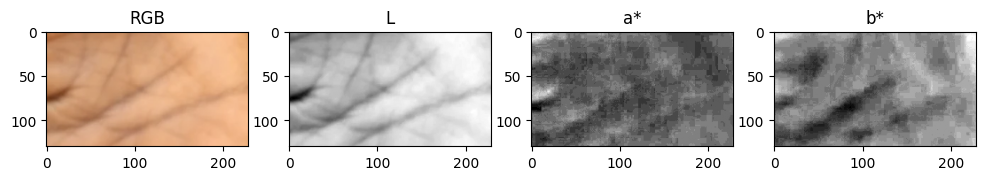

In [11]:
import matplotlib.pyplot as plt

row = df_exp.iloc[0]

img = cv2.imread(row["path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

L,a,b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,4,2)
plt.imshow(L,cmap="gray")
plt.title("L")

plt.subplot(1,4,3)
plt.imshow(a,cmap="gray")
plt.title("a*")

plt.subplot(1,4,4)
plt.imshow(b,cmap="gray")
plt.title("b*")

plt.show()

In [12]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3366, 36)
Test: (894, 36)


In [13]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
     "Naive Bayes": GaussianNB(var_smoothing=1e+1),
     "SVM": SVC(
     kernel="rbf",
     C=50,
     gamma="auto",
     probability=True,
     random_state=42
),
    "KNN": KNeighborsClassifier(n_neighbors=1),
    "Decision Tree": DecisionTreeClassifier(
     criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
     max_depth=26,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
     min_samples_split=2,    # Dallanmak için gereken minimum örnek sayısı
     min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
     max_features=2,      # Bölmede kullanılacak maksimum özellik sayısı
     random_state=42
),
  "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=500,        # Kaç ağaç kullanılacağı, default 100. Daha fazla → genellikle daha iyi performans
    learning_rate=0.5,      # Her ağacın katkısı, default 0.1. Küçük değer → daha stabil öğrenme
    max_depth=3,             # Ağaç derinliği, default 3. Daha derin → overfitting riski
    min_samples_split=2,     # Dallanma için minimum örnek sayısı
    min_samples_leaf=1,      # Yaprak başına minimum örnek sayısı
    subsample=0.8,           # Rastgele alt örnekleme oranı, 0.8 → overfitting azaltır
    max_features=None,       # Her ağacı oluştururken kullanılacak özellik sayısı
    random_state=42
),

  "XGBoost": XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=1,
    colsample_bytree=0.95,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
),

  "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),

  "AdaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=2),      # Temel öğrenici, default DecisionTreeClassifier(max_depth=1)
    n_estimators=1000,          # Kaç ağaç/estimator oluşturulacağı, default 50
    learning_rate=1,        # Her estimator’un katkı ağırlığı, default 1.0
    random_state=42
),

    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
)
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Naive Bayes
10-fold Group CV mean: 0.6027918950631734
std: 0.015498418474165434

SVM
10-fold Group CV mean: 0.6272191393531056
std: 0.02026908124013352

KNN
10-fold Group CV mean: 0.6819384379221789
std: 0.07494609550830005

Decision Tree
10-fold Group CV mean: 0.6765357424817534
std: 0.05321679480825493

Gradient Boosting
10-fold Group CV mean: 0.7524211345776469
std: 0.06843258826422781

XGBoost
10-fold Group CV mean: 0.7601891451963707
std: 0.062430105415157776

CatBoost
10-fold Group CV mean: 0.763367639512488
std: 0.07201369513641341

AdaBoost
10-fold Group CV mean: 0.7876205974655104
std: 0.05655188962050839

HistGradientBoosting
10-fold Group CV mean: 0.7765761886204985
std: 0.07468876684852294


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
     "Naive Bayes": GaussianNB(var_smoothing=1e+1),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Naive Bayes
10-fold Group CV mean: 0.6027918950631734
std: 0.015498418474165434


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=1,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    random_state=42
),
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


HistGradientBoosting
10-fold Group CV mean: 0.7667496221426335
std: 0.0635531203793699


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # bazı modellerde predict_proba olmayabilir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": round(acc*100,4),
        "F1-score": round(f1*100,4),
        "AUC": round(auc*100,4),
        "Precision": round(prec*100,4),
        "Recall": round(rec*100,4)
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,F1-score,AUC,Precision,Recall
0,Naive Bayes,59.7315,74.7899,55.1498,59.7315,100.0000
1,SVM,63.7584,76.5217,76.1798,62.4113,98.8764
2,KNN,71.1409,75.1445,70.6835,77.3810,73.0337
3,Decision Tree,67.7852,73.3333,66.2453,72.5275,74.1573
4,Gradient Boosting,79.1946,82.6816,81.3296,82.2222,83.1461
5,XGBoost,77.8523,81.7680,80.7491,80.4348,83.1461
6,CatBoost,78.5235,82.4176,78.6330,80.6452,84.2697
7,AdaBoost,79.1946,82.8729,82.0225,81.5217,84.2697
8,HistGradientBoosting,79.8658,83.5165,82.2472,81.7204,85.3933


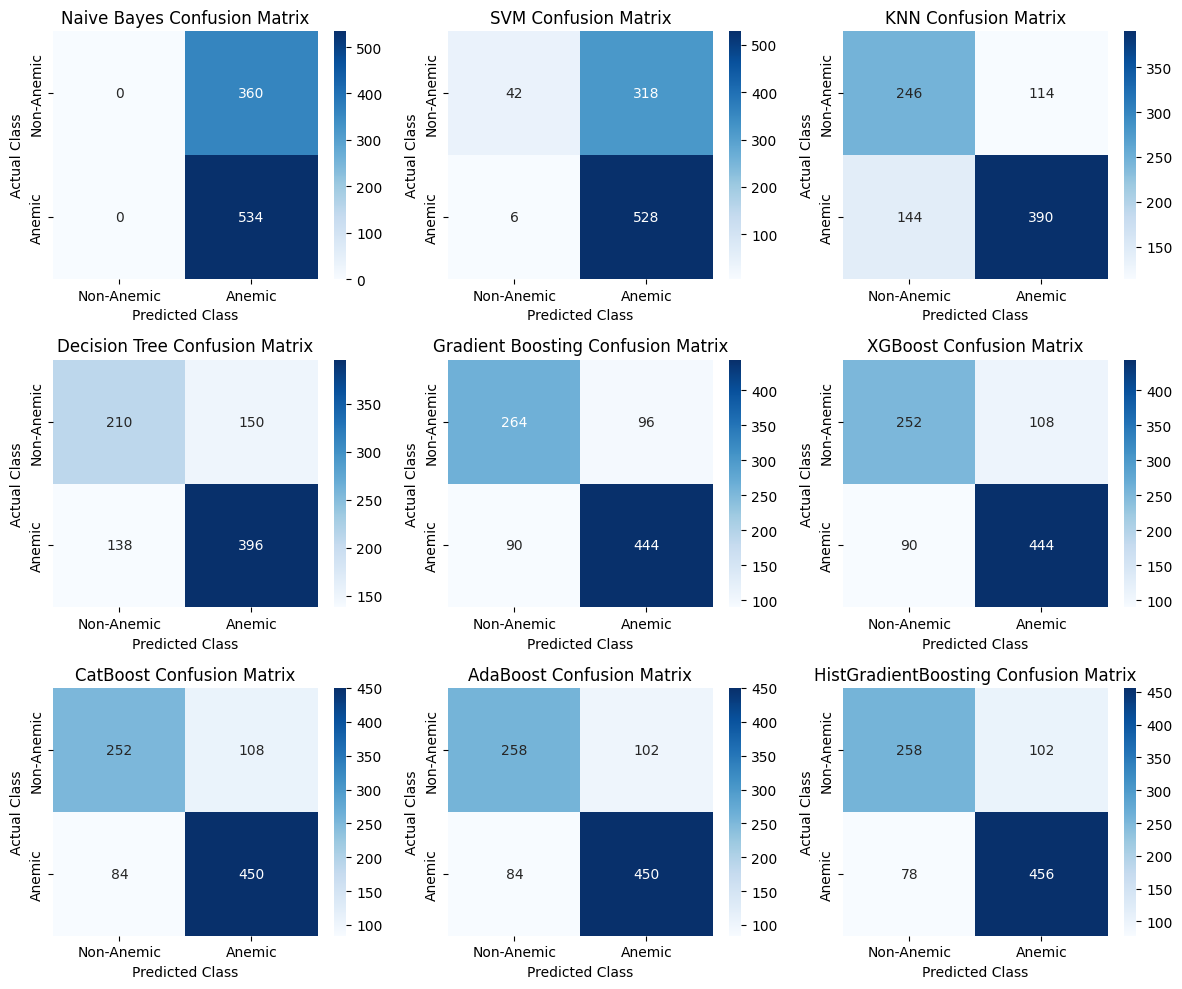

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,3, figsize=(12,10))

axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Non-Anemic","Anemic"],
        yticklabels=["Non-Anemic","Anemic"]
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

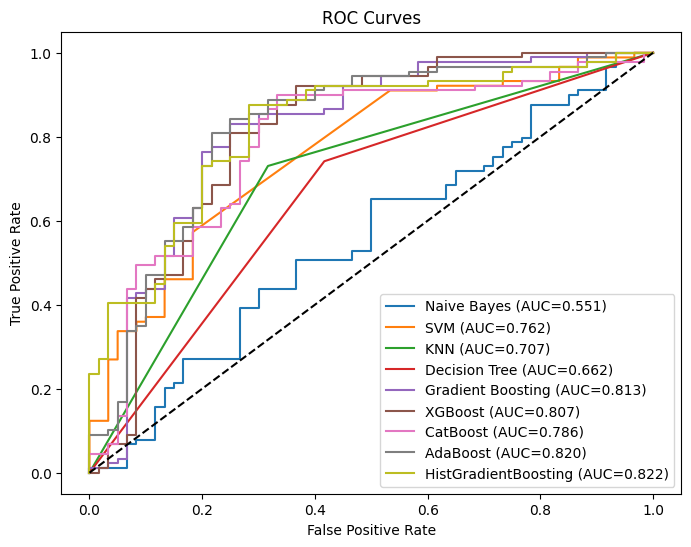

In [17]:
from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = sk_auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "palm_models"
os.makedirs(model_folder, exist_ok=True)

for name, model in models.items():
    # Modeli dosyaya kaydet
    filename = os.path.join(model_folder, f"{name.replace(' ','_')}.joblib")
    joblib.dump(model, filename)
    print(f"{name} kaydedildi → {filename}")

Naive Bayes kaydedildi → palm_models/Naive_Bayes.joblib
SVM kaydedildi → palm_models/SVM.joblib
KNN kaydedildi → palm_models/KNN.joblib
Decision Tree kaydedildi → palm_models/Decision_Tree.joblib
Gradient Boosting kaydedildi → palm_models/Gradient_Boosting.joblib
XGBoost kaydedildi → palm_models/XGBoost.joblib
CatBoost kaydedildi → palm_models/CatBoost.joblib
AdaBoost kaydedildi → palm_models/AdaBoost.joblib
HistGradientBoosting kaydedildi → palm_models/HistGradientBoosting.joblib


In [18]:
print(np.bincount(y_train))
print(np.bincount(y_test))

[1338 2028]
[360 534]



LightGBM
10-fold Group CV mean accuracy: 0.7667570016334049
10-fold Group CV std: 0.06663283542743952
  Algorithm  Accuracy  F1-score      AUC  Precision   Recall
0  LightGBM   79.8658   83.6957  82.0599    81.0526  86.5169


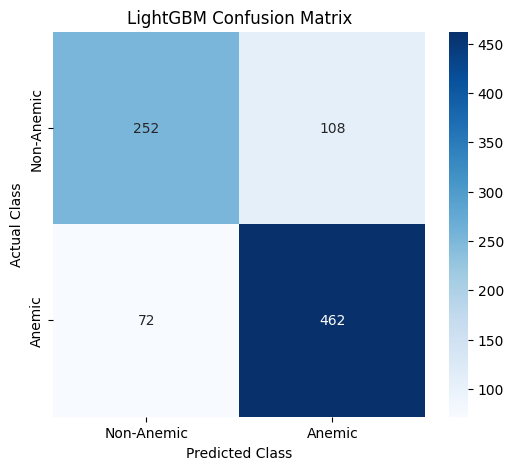

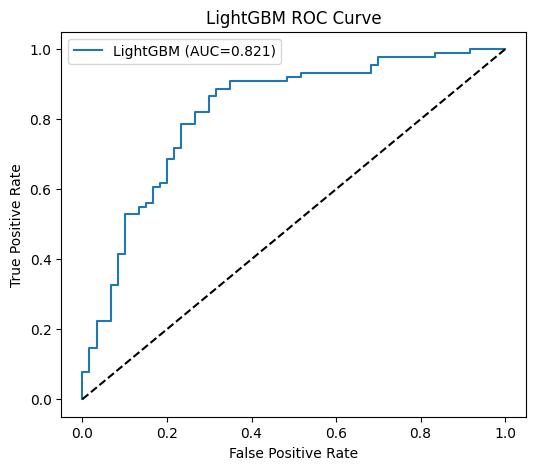

In [19]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc as sk_auc
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# LightGBM için dataframe (FULL FEATURE SET)
# -----------------------------------
feature_names = [
    # RGB
    "R_mean","R_std","G_mean","G_std","B_mean","B_std",

    # LAB
    "L_mean","L_std","a_mean","a_std","b_mean","b_std",

    # HSV
    "H_mean","H_std","S_mean","S_std","V_mean","V_std",

    # Percentiles RGB
    "R_p25","R_p50","R_p75",
    "G_p25","G_p50","G_p75",
    "B_p25","B_p50","B_p75",

    # Ratios
    "R_G","R_B","G_B",
    "R_ratio","G_ratio","B_ratio",

    # Gray texture
    "gray_mean","gray_std","gray_var"
]

X_train_lgb = pd.DataFrame(X_train, columns=feature_names)
X_test_lgb = pd.DataFrame(X_test, columns=feature_names)

# -----------------------------------
# LightGBM modeli
# -----------------------------------
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    verbose=-1
)

# -----------------------------------
# GROUP BASED CROSS VALIDATION
# -----------------------------------
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    lgb_model,
    X_train_lgb,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="accuracy"
)

print("\nLightGBM")
print("10-fold Group CV mean accuracy:", scores.mean())
print("10-fold Group CV std:", scores.std())

# -----------------------------------
# TRAIN
# -----------------------------------
lgb_model.fit(X_train_lgb, y_train)

# -----------------------------------
# TEST
# -----------------------------------
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

# -----------------------------------
# METRICS
# -----------------------------------
acc = accuracy_score(y_test, y_pred_lgb)
prec = precision_score(y_test, y_pred_lgb)
rec = recall_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb)
auc = roc_auc_score(y_test, y_prob_lgb)

results_lgb = pd.DataFrame([{
    "Algorithm": "LightGBM",
    "Accuracy": round(acc * 100, 4),
    "F1-score": round(f1 * 100, 4),
    "AUC": round(auc * 100, 4),
    "Precision": round(prec * 100, 4),
    "Recall": round(rec * 100, 4)
}])

print(results_lgb)

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Anemic", "Anemic"],
    yticklabels=["Non-Anemic", "Anemic"]
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# -----------------------------------
# ROC CURVE
# -----------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()

plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "palm_models"

# LightGBM modelini kaydet
filename = os.path.join(model_folder, "LightGBM_model.joblib")
joblib.dump(lgb_model, filename)
print(f"LightGBM modeli kaydedildi → {filename}")

LightGBM modeli kaydedildi → palm_models/LightGBM_model.joblib
